In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
# Constants
v = +1 if np.random.rand() < 0.5 else -1
l1 = 500
l = 500
l2 = 1000
L = 1000
L0 = 5
p0 = 0.9

# 1 . Position distribution

In [3]:
dist = np.arange(1,L+1)
concentration_1 = (np.sin(2*np.pi * dist / l)) + L0

UIC = []

p = 0
for k in range(3):
    for j in range(1,1001):
        UIC.append(j + p)
    p += 0.33

In [4]:
# State function :
def get_state(position):
    return 0 if concentration_1[position] >= L0 else 1

In [10]:
def qlearning(alpha , epsilon , T , concentration , initial_position , v = +1 ):
    final_position = []
    for position in initial_position:
        pos = position
        pos_old = pos
        pos_old2 = pos

        posi_ = []
        Q = np.zeros((2,2))
    
        for _ in range(T):
            state = get_state(int(pos) - 1)
            if np.random.rand() < p0:
                action = 0
            else:
                c_l1 = concentration[int(pos_old - 1)]
                c_l2 = concentration[int(pos_old2 - 1)]
                if c_l1 >= c_l2:
                    cost_persist, cost_reverse = 0, 1
                elif c_l1 < c_l2:
                    cost_persist, cost_reverse = 1, 0
        
                if np.random.rand() < epsilon:
                    action = np.random.choice([0,1])
                else:
                    qvals = Q[state]
                    min_actions = np.where(qvals == qvals.min())[0]
                    action = np.random.choice(min_actions)
        
                cost = cost_persist if action == 0 else cost_reverse
                oldQ = Q[state, action]
                Q[state, action] = (1 - alpha)*oldQ + alpha * (cost)

            if action == 0:
                pos_new = (pos + v) % L
                pos_old2, pos_old = pos_old, pos
                pos = pos_new
            else:
                v = -v
     
            posi_.append(pos)
        final_position.append(posi_)
    return final_position

In [11]:
def circular_direction(a, b, max_val=999):
    if a == b:
        return 0
    forward = (b - a) % max_val
    backward = (a - b) % max_val
    return 1 if forward < backward else -1

def count_circular_turning_points(arr, max_val=999):
    arr = np.array(arr)
    if len(arr) < 2:
        return 0

    turning_points = 0
    prev_direction = 0

    for i in range(1, len(arr)):
        direction = circular_direction(arr[i-1], arr[i], max_val)
        
        if direction == 0:
            continue  # skip if no movement

        if prev_direction != 0 and direction != prev_direction:
            turning_points += 1
        prev_direction = direction

    return turning_points

In [12]:
def list_to_avg(l):
    res = []
    i = 0
    for ele in l:
        c = count_circular_turning_points(ele)
        if c == 0:
            c = 1
        res.append(len(ele) / c)
    return np.mean(res)

In [13]:
epsilons_alphas = [(0.001,0.1),(0.01,0.2),(0.05,0.2)]

In [14]:
mrd_0 = []
list_0 = []
for (e,a) in epsilons_alphas:
    T = 1000
    list_ = qlearning(a , e , T , concentration_1 , initial_position = UIC )
    mrd_0.append(list_to_avg(list_))
    list_0.append(list_)

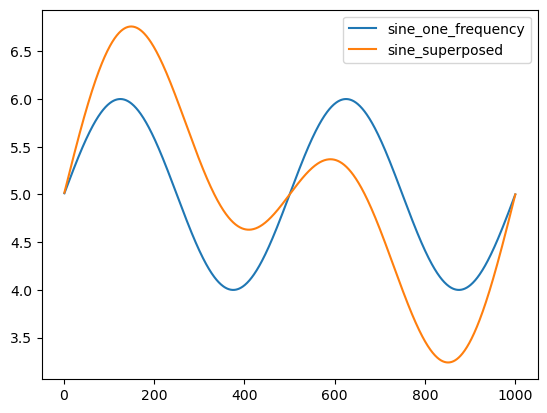

In [15]:
x_d = np.arange(1,1001)
f1_v = np.sin(2*np.pi*x_d/500) + 5
f2_v = np.sin(2*np.pi*x_d/500) + np.sin(2*np.pi*x_d/1000) + 5
plt.plot(x_d,f1_v,label = 'sine_one_frequency')
plt.plot(x_d,f2_v,label = 'sine_superposed')
plt.legend();

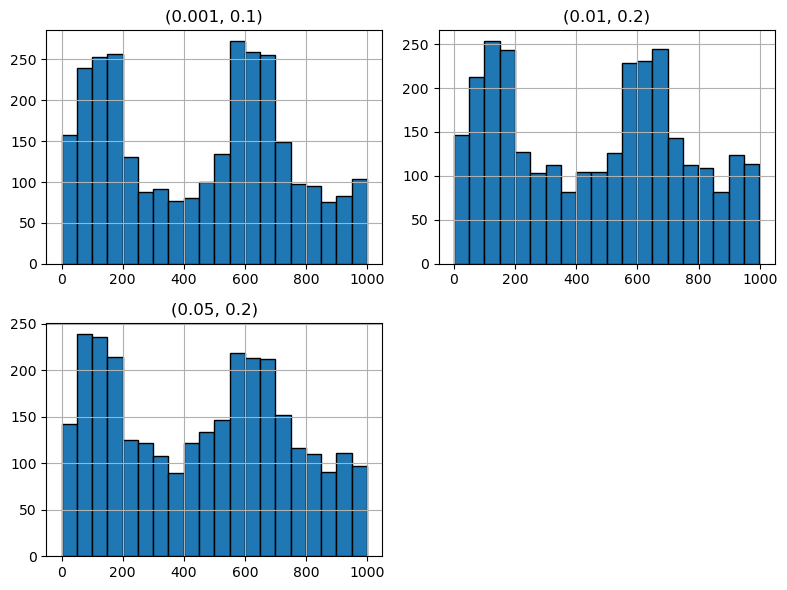

In [16]:
num_plots = len(list_0)
names = epsilons_alphas

rows = math.ceil(math.sqrt(num_plots))
cols = math.ceil(num_plots / rows)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten()

for i in range(num_plots):
    finaly = [ele[-1] for ele in list_0[i]]
    axes[i].hist(finaly, bins=20, edgecolor='black')
    title = names[i] if i < len(names) else f"Group {i+1}"
    axes[i].set_title(title)
    axes[i].grid(True)

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 2 . Mean run duration

In [25]:
dist = np.arange(1,L+1)
concentration_1 = (np.sin(2*np.pi * dist / l)) + L0

UIC = []

for k in range(3):
    for j in range(1,1001):
        UIC.append(j)
    
# State function :
def get_state(position):
    return 0 if concentration_1[position] >= L0 else 1

def qlearning(alpha , epsilon , T , concentration , initial_position , v = +1 ):
    final_position = []
    for position in initial_position:
        pos = position
        pos_old = pos
        pos_old2 = pos

        posi_ = []
        Q = np.zeros((2,2))
    
        for _ in range(T):
            state = get_state(pos - 1)
            if np.random.rand() < p0:
                action = 0
            else:
                c_l1 = concentration[pos_old - 1]
                c_l2 = concentration[pos_old2 - 1]
                if c_l1 >= c_l2:
                    cost_persist, cost_reverse = 0, 1
                elif c_l1 < c_l2:
                    cost_persist, cost_reverse = 1, 0
        
                if np.random.rand() < epsilon:
                    action = np.random.choice([0,1])
                else:
                    qvals = Q[state]
                    min_actions = np.where(qvals == qvals.min())[0]
                    action = np.random.choice(min_actions)
        
                cost = cost_persist if action == 0 else cost_reverse
                oldQ = Q[state, action]
                Q[state, action] = (1 - alpha)*oldQ + alpha * (cost)

            if action == 0:
                pos_new = (pos + v) % L
                pos_old2, pos_old = pos_old, pos
                pos = pos_new
            else:
                v = -v
     
            posi_.append(pos)
        final_position.append(posi_)
    return final_position


# given a list of positions find the average run duration :
def circular_direction(a, b, max_val=999):
    if a == b:
        return 0
    forward = (b - a) % max_val
    backward = (a - b) % max_val
    return 1 if forward < backward else -1

def count_circular_turning_points(arr, max_val=999):
    arr = np.array(arr)
    if len(arr) < 2:
        return 0

    turning_points = 0
    prev_direction = 0

    for i in range(1, len(arr)):
        direction = circular_direction(arr[i-1], arr[i], max_val)
        
        if direction == 0:
            continue  # skip if no movement

        if prev_direction != 0 and direction != prev_direction:
            turning_points += 1
        prev_direction = direction

    return turning_points

def list_to_avg(l):
    res = []
    i = 0
    for ele in l:
        c = count_circular_turning_points(ele)
        if c == 0:
            c = 1
        res.append(len(ele) / c)
    return np.mean(res)

alpha_ = 0.01
es_ = np.linspace(0,1,15)

mrd_1 = []
list_1 = []
for e in es_:
    T = 1000
    list_ = qlearning(alpha_ , e , T , concentration_1 , initial_position = UIC )
    mrd_1.append(list_to_avg(list_))
    list_1.append(list_)

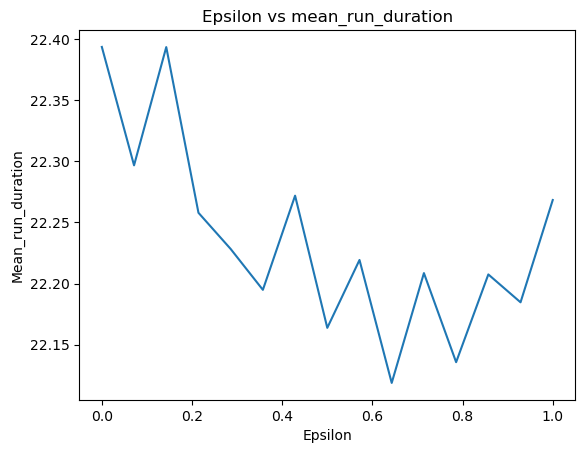

In [26]:
plt.plot(es_ , mrd_1)
plt.title('Epsilon vs mean_run_duration')
plt.xlabel('Epsilon')
plt.ylabel('Mean_run_duration');

# 3 . Uptake vs Epsilon

In [9]:
dist = np.arange(1,L+1)
concentration_1 = (np.sin(2*np.pi * dist / l)) + L0

UIC = []

for k in range(3):
    for j in range(1,1001):
        UIC.append(j)

# State function :
def get_state(position):
    return 0 if concentration_1[position] >= L0 else 1


def qlearning(alpha , epsilon , T , concentration , initial_position , v = +1 ):
    final_position = []
    for position in initial_position:
        pos = position
        pos_old = pos
        pos_old2 = pos

        posi_ = []
        Q = np.zeros((2,2))
    
        for _ in range(T):
            state = get_state(pos - 1)
            if np.random.rand() < p0:
                action = 0
            else:
                c_l1 = concentration[pos_old - 1]
                c_l2 = concentration[pos_old2 - 1]
                if c_l1 >= c_l2:
                    cost_persist, cost_reverse = 0, 1
                elif c_l1 < c_l2:
                    cost_persist, cost_reverse = 1, 0
        
                if np.random.rand() < epsilon:
                    action = np.random.choice([0,1])
                else:
                    qvals = Q[state]
                    min_actions = np.where(qvals == qvals.min())[0]
                    action = np.random.choice(min_actions)
        
                cost = cost_persist if action == 0 else cost_reverse
                oldQ = Q[state, action]
                Q[state, action] = (1 - alpha)*oldQ + alpha * (cost)

            if action == 0:
                pos_new = (pos + v) % L
                pos_old2, pos_old = pos_old, pos
                pos = pos_new
            else:
                v = -v
     
            posi_.append(pos)
        final_position.append(posi_)
    return final_position

def circular_direction(a, b, max_val=999):
    if a == b:
        return 0
    forward = (b - a) % max_val
    backward = (a - b) % max_val
    return 1 if forward < backward else -1

def count_circular_turning_points(arr, max_val=999):
    arr = np.array(arr)
    if len(arr) < 2:
        return 0

    turning_points = 0
    prev_direction = 0

    for i in range(1, len(arr)):
        direction = circular_direction(arr[i-1], arr[i], max_val)
        
        if direction == 0:
            continue  # skip if no movement

        if prev_direction != 0 and direction != prev_direction:
            turning_points += 1
        prev_direction = direction

    return turning_points

def list_to_avg(l):
    res = []
    i = 0
    for ele in l:
        c = count_circular_turning_points(ele)
        if c == 0:
            c = 1
        res.append(len(ele) / c)
    return np.mean(res)

epsilon_range = np.linspace(0,1,20)
alpha = 0.2

mrd_3 = []
list_3 = []
for e in epsilon_range:
    T = 1000
    list_ = qlearning(alpha , e , T , concentration_1 , initial_position = UIC )
    mrd_3.append(list_to_avg(list_))
    list_3.append(list_)

In [10]:
c = []
for ele in list_3:
    e = [i[-1] for i in ele]
    L = 1000
    counts = np.bincount(e, minlength=L+1)[1:]  
    Px = counts / np.sum(counts)                     
    x_vals = np.arange(1, L+1)
    Lx = np.sin(2 * np.pi * x_vals / 500)
    C_avg = np.sum(Px * Lx)
    c.append(C_avg)

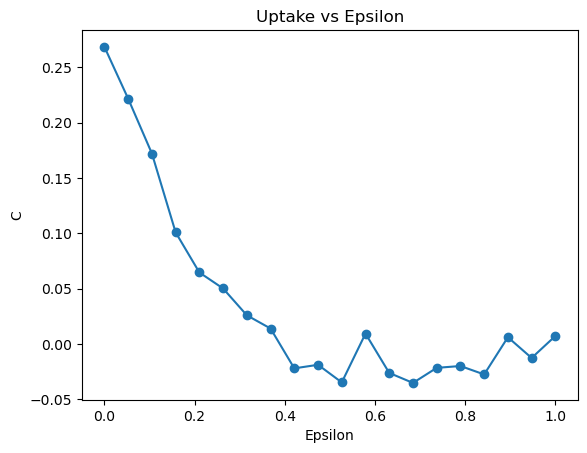

In [11]:
plt.scatter(epsilon_range , c)
plt.plot(epsilon_range , c)
plt.xlabel('Epsilon')
plt.ylabel('C(uptake)')
plt.title('Uptake vs Epsilon')
plt.xlabel('Epsilon')
plt.ylabel('C')
plt.title('Uptake vs Epsilon');

# 4 . Uptake vs Alpha

In [16]:
dist = np.arange(1,L+1)
concentration_1 = (np.sin(2*np.pi * dist / l)) + L0

UIC = []

for k in range(3):
    for j in range(1,1001):
        UIC.append(j)

# State function :
def get_state(position):
    return 0 if concentration_1[position] >= L0 else 1


def qlearning(alpha , epsilon , T , concentration , initial_position , v = +1 ):
    final_position = []
    for position in initial_position:
        pos = position
        pos_old = pos
        pos_old2 = pos

        posi_ = []
        Q = np.zeros((2,2))
    
        for _ in range(T):
            state = get_state(pos - 1)
            if np.random.rand() < p0:
                action = 0
            else:
                c_l1 = concentration[pos_old - 1]
                c_l2 = concentration[pos_old2 - 1]
                if c_l1 >= c_l2:
                    cost_persist, cost_reverse = 0, 1
                elif c_l1 < c_l2:
                    cost_persist, cost_reverse = 1, 0
        
                if np.random.rand() < epsilon:
                    action = np.random.choice([0,1])
                else:
                    qvals = Q[state]
                    min_actions = np.where(qvals == qvals.min())[0]
                    action = np.random.choice(min_actions)
        
                cost = cost_persist if action == 0 else cost_reverse
                oldQ = Q[state, action]
                Q[state, action] = (1 - alpha)*oldQ + alpha * (cost)

            if action == 0:
                pos_new = (pos + v) % L
                pos_old2, pos_old = pos_old, pos
                pos = pos_new
            else:
                v = -v
     
            posi_.append(pos)
        final_position.append(posi_)
    return final_position


# given a list of positions find the average run duration :
def circular_direction(a, b, max_val=999):
    if a == b:
        return 0
    forward = (b - a) % max_val
    backward = (a - b) % max_val
    return 1 if forward < backward else -1

def count_circular_turning_points(arr, max_val=999):
    arr = np.array(arr)
    if len(arr) < 2:
        return 0

    turning_points = 0
    prev_direction = 0

    for i in range(1, len(arr)):
        direction = circular_direction(arr[i-1], arr[i], max_val)
        
        if direction == 0:
            continue  # skip if no movement

        if prev_direction != 0 and direction != prev_direction:
            turning_points += 1
        prev_direction = direction

    return turning_points

def list_to_avg(l):
    res = []
    i = 0
    for ele in l:
        c = count_circular_turning_points(ele)
        if c == 0:
            c = 1
        res.append(len(ele) / c)
    return np.mean(res)


a4 = np.linspace(0,0.03,25)
e = 0.001

mrd_4 = []
list_4 = []
for a in a4:
    T = 1000
    list_ = qlearning(a , e , T , concentration_1 , initial_position = UIC )
    mrd_4.append(list_to_avg(list_))
    list_4.append(list_)

In [17]:
c4 = []
for ele in list_4:
    e = [i[-1] for i in ele]
    L = 1000
    counts = np.bincount(e, minlength=L+1)[1:]  
    Px = counts / np.sum(counts)                     
    x_vals = np.arange(1, L+1)
    Lx = np.sin(2 * np.pi * x_vals / 500) + np.sin(2 * np.pi * x_vals / 1000)
    C_avg = np.sum(Px * Lx)
    c4.append(C_avg)

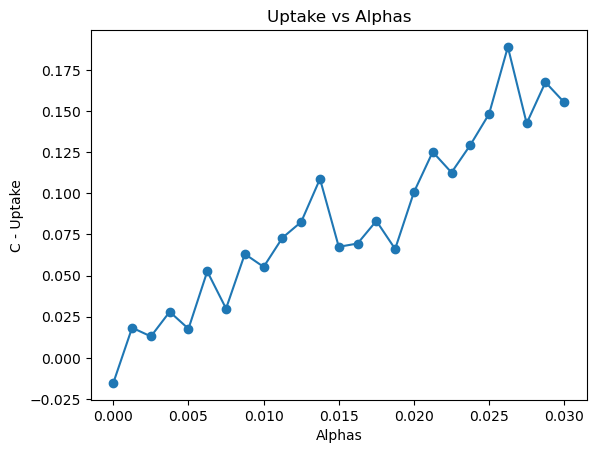

In [18]:
plt.scatter(a4 , c4)
plt.plot(a4 , c4)
plt.xlabel('Alphas')
plt.ylabel('C - Uptake')
plt.title('Uptake vs Alphas');